# Libraries

In [ ]:
import os, re, warnings, nltk
import pandas as pd, seaborn as sns
import matplotlib.pyplot as plt
from string import digits, whitespace
from IPython.display import display, Markdown
from nltk.corpus import stopwords  

warnings.filterwarnings('ignore')

Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


here is the data from another splitted dataset which can be potentially used in the model training or validation

In [ ]:
# pd.set_option('display.max_colwidth', None)
# path = './dataset_5_1'
# os.listdir(path)
# train_neg_path = path+'/train/pos'
# files = [f for f in os.listdir(train_neg_path) if f.lower().endswith('.txt')]
# files = sorted(files) 

# rows = []
# for i, fname in enumerate(files, start=1):
#     file_path = os.path.join(train_neg_path, fname)
#     with open(file_path, 'r', encoding='utf-8') as fh:
#         text = fh.read()
#     rows.append({'filename': fname, 'text': text})
# df_docs = pd.DataFrame(rows)
# display(df_docs.head(2))
# df_docs.text[0]

# Data analysis and cleaning

In [ ]:
test = pd.read_csv('data/test_tg.csv')
train = pd.read_csv('data/train_tg.csv')
val = pd.read_csv('data/val.csv')

test.head()
cols_to_drop = ['Unnamed: 0','peer_id.channel_id', 'id','fwd_from.from_id.channel_id', 'media._', 'media.webpage.type', 'channel_name', 'media.webpage.url', 'media.webpage.description', 'media.webpage.title']

test = test.drop(columns=cols_to_drop)
train = train.drop(columns=cols_to_drop)
val = val.drop(columns=cols_to_drop)

In [ ]:
train.head(2)

,date,message,views,forwards,label
0,2022-02-19T15:23:08+00:00,"Зеленский сообщил, что настаивает на введении ...",41389.0,60.0,1
1,2022-02-18T15:39:01+00:00,Очень тревожно на Донбассе. Очень…,24552.0,6.0,0


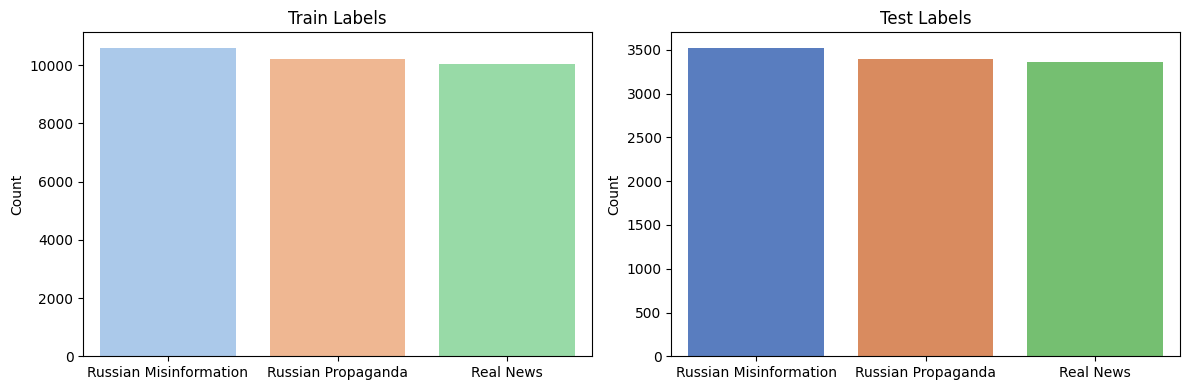

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
label_counts_train = train["label"].value_counts()
label_map = {0: 'Russian Misinformation', 1: 'Russian Propaganda', 2: 'Real News'}
train['label_text'] = train['label'].map(label_map)
# Indexes:
# 0 - Russian Misinformation
# 1 - Russian Propaganda
# 2 - Real News
sns.barplot(x=label_map.values(), y=label_counts_train.values, palette="pastel", ax=axes[0])
axes[0].set_title("Train Labels")
axes[0].set_ylabel("Count")

label_counts_test = test["label"].value_counts()
sns.barplot(x=label_map.values(), y=label_counts_test.values, palette="muted", ax=axes[1])
axes[1].set_title("Test Labels")
axes[1].set_ylabel("Count")
plt.tight_layout()
plt.show()

In [ ]:
train["message_length"] = train["message"].apply(lambda x: len(str(x).split()))
test["message_length"] = test["message"].apply(lambda x: len(str(x).split()))
display(Markdown("**Train data:**"))
display(train["message_length"].describe().to_frame())
display(Markdown("**Train data:**"))
display(test["message_length"].describe().to_frame())

**Train data:**

,message_length
count,30844.000000
mean,50.621839
std,63.909924
min,1.000000
25%,16.000000
50%,29.000000
75%,62.000000
max,683.000000


**Train data:**

,message_length
count,10282.000000
mean,52.730597
std,67.809822
min,1.000000
25%,16.000000
50%,29.000000
75%,64.000000
max,637.000000


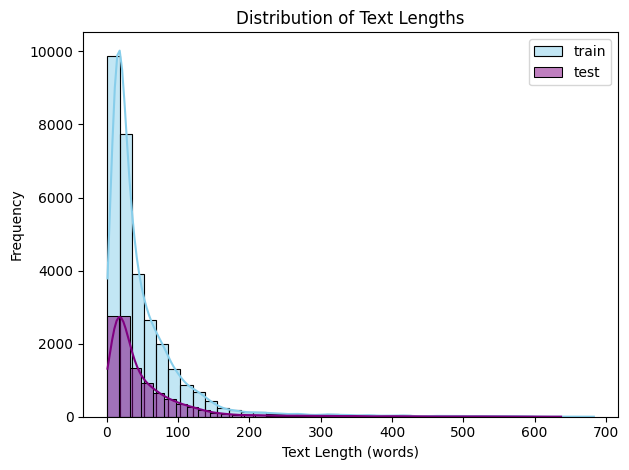

In [ ]:
sns.histplot(train["message_length"], bins=40, kde=True, color="skyblue", label = 'train')
sns.histplot(test["message_length"], bins=40, kde=True, color="purple", label = 'test')
plt.title("Distribution of Text Lengths")
plt.xlabel("Text Length (words)")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
for df in [test, train]:
    q_low = df["message_length"].quantile(0.10)
    df = df[df["message_length"] > q_low]

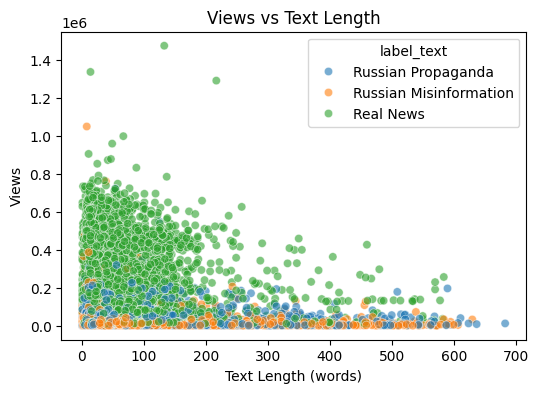

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    data=train, 
    x="message_length", 
    y="views", 
    hue="label_text",
    alpha=0.6,
)
plt.title("Views vs Text Length")
plt.xlabel("Text Length (words)")
plt.ylabel("Views")
plt.show()

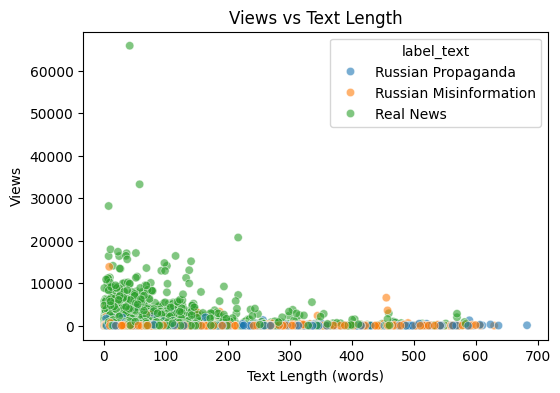

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    data=train, 
    x="message_length", 
    y="forwards", 
    hue="label_text", 
    alpha=0.6,
)
plt.title("Views vs Text Length")
plt.xlabel("Text Length (words)")
plt.ylabel("Views")
plt.show()

In [ ]:
train["date"] = pd.to_datetime(train["date"], errors="coerce")
test["date"] = pd.to_datetime(test["date"], errors="coerce")
val["date"] = pd.to_datetime(val["date"], errors="coerce")

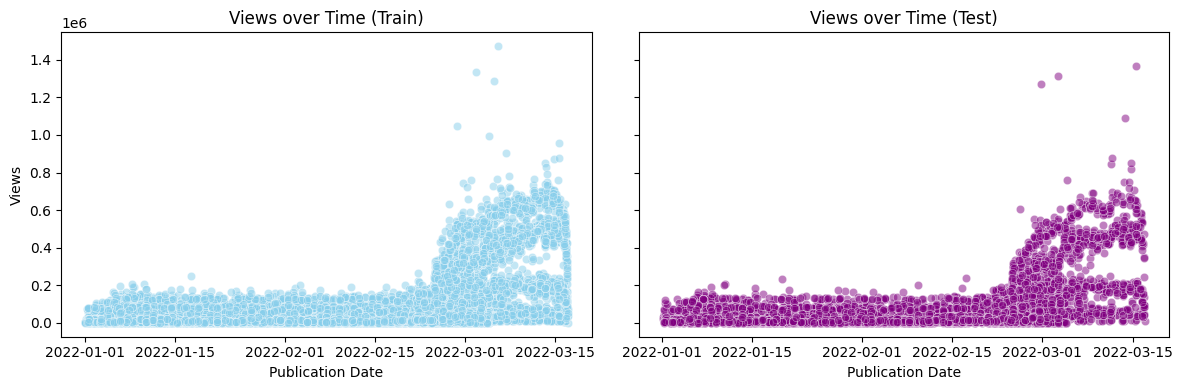

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

sns.scatterplot(data=train, x="date", y="views", alpha=0.5, ax=axes[0], color="skyblue")
axes[0].set_title("Views over Time (Train)")
axes[0].set_xlabel("Publication Date")
axes[0].set_ylabel("Views")

sns.scatterplot(data=test, x="date", y="views", alpha=0.5, ax=axes[1], color="purple")
axes[1].set_title("Views over Time (Test)")
axes[1].set_xlabel("Publication Date")
axes[1].set_ylabel("Views")

plt.tight_layout()
plt.show()


In [ ]:
test.head(2)

,date,message,views,forwards,label,message_length
0,2022-02-07 14:30:05+00:00,О чем можно договориться с Западом в вопросах ...,15662.0,15.0,2,34
1,2022-03-02 23:51:56+00:00,"""Зарплата маленькая"". Пленный рассказал, почем...",26132.0,53.0,0,64


In [ ]:
def remove_urls(text):
    url_pattern = r'http\S+|https\S+|t.me\S+'
    cleaned_text = re.sub(url_pattern, '', text)
    return cleaned_text

train['message'] = train.message.apply(remove_urls)
test['message'] = test.message.apply(remove_urls)
val['message'] = val.message.apply(remove_urls)

In [ ]:
train["message"] = train["message"].str.replace(r"[\n\t]", " ", regex=True)
test["message"] = test["message"].str.replace(r"[\n\t]", " ", regex=True)
val["message"] = val["message"].str.replace(r"[\n\t]", " ", regex=True)

In [ ]:
train.message = train.message.str.replace(r'@\w+\s?', '', regex=True)
train.message = train.message.str.lower()

test.message = test.message.str.replace(r'@\w+\s?', '', regex=True)
test.message = test.message.str.lower()

val.message = val.message.str.replace(r'@\w+\s?', '', regex=True)
val.message = val.message.str.lower()

In [ ]:
cyrillic_letters = u"абвгдеёжзийклмнопрстуфхцчшщъыьэюя"

def strip_chars(text):
    allowed_chars = cyrillic_letters + digits + whitespace
    return "".join([c for c in text if c in allowed_chars]).strip()

train.message = train.message.apply(strip_chars)
test.message = test.message.apply(strip_chars)
val.message = val.message.apply(strip_chars)

In [ ]:
train.message = train.message.str.replace(r'\s+', ' ', regex=True)
test.message = test.message.str.replace(r'\s+', ' ', regex=True)
val.message = val.message.str.replace(r'\s+', ' ', regex=True)

In [ ]:
train.head(10)

,date,message,views,forwards,label,label_text,message_length
0,2022-02-19 15:23:08+00:00,зеленский сообщил что настаивает на введении с...,41389.0,60.0,1,Russian Propaganda,13
1,2022-02-18 15:39:01+00:00,очень тревожно на донбассе очень,24552.0,6.0,0,Russian Misinformation,5
2,2022-02-24 18:37:53+00:00,подписчики сообщают что все цветочные магазины...,43939.0,160.0,0,Russian Misinformation,13
3,2022-02-10 17:34:25+00:00,ох как прав леонид эдуардович уважаемый с этим...,2514.0,1.0,0,Russian Misinformation,55
4,2022-02-21 11:28:17+00:00,политсоветники нормандской четверки смогут вст...,23272.0,21.0,0,Russian Misinformation,17
5,2022-01-24 13:07:06+00:00,киевская экономика пожухла таллин наконецто уз...,18849.0,12.0,0,Russian Misinformation,12
6,2022-01-19 14:57:10+00:00,фермеры новой зеландии готовы работать только ...,2435.0,3.0,1,Russian Propaganda,26
7,2022-02-23 08:57:51+00:00,весь мариуполь вышел в полночь к драмтеатру чт...,1993.0,8.0,0,Russian Misinformation,28
8,2022-02-10 09:01:06+00:00,по старому анекдоту первое что спросил папа ри...,15111.0,77.0,2,Real News,26
9,2022-03-03 13:01:05+00:00,криптобиржа сообщила что ограничила доступ дер...,338424.0,835.0,2,Real News,15


In [ ]:
train = train.dropna()
test = test.dropna()
val = val.dropna()

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30774 entries, 0 to 30843
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype              
---  ------          --------------  -----              
 0   date            30774 non-null  datetime64[ns, UTC]
 1   message         30774 non-null  object             
 2   views           30774 non-null  float64            
 3   forwards        30774 non-null  float64            
 4   label           30774 non-null  int64              
 5   label_text      30774 non-null  object             
 6   message_length  30774 non-null  int64              
dtypes: datetime64[ns, UTC](1), float64(2), int64(2), object(2)
memory usage: 1.9+ MB


## Removing stopwords

In [ ]:
nltk.download('stopwords')
stop_ru = set(stopwords.words('russian'))

[nltk_data] Downloading package stopwords to /home/gllekk/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
def remove_stopwords(text):
    text = str(text).lower()
    tokens = re.findall(r'\w+', text, flags=re.UNICODE)
    filtered = [t for t in tokens if t not in stop_ru]
    return ' '.join(filtered)

train['message_nostop'] = train['message'].apply(remove_stopwords)
test['message_nostop'] = test['message'].apply(remove_stopwords)
val['message_nostop'] = val['message'].apply(remove_stopwords)


In [ ]:
train

,date,message,views,forwards,label,label_text,message_length,message_nostop
0,2022-02-19 15:23:08+00:00,зеленский сообщил что настаивает на введении с...,41389.0,60.0,1,Russian Propaganda,13,зеленский сообщил настаивает введении санкций ...
1,2022-02-18 15:39:01+00:00,очень тревожно на донбассе очень,24552.0,6.0,0,Russian Misinformation,5,очень тревожно донбассе очень
2,2022-02-24 18:37:53+00:00,подписчики сообщают что все цветочные магазины...,43939.0,160.0,0,Russian Misinformation,13,подписчики сообщают цветочные магазины киева п...
3,2022-02-10 17:34:25+00:00,ох как прав леонид эдуардович уважаемый с этим...,2514.0,1.0,0,Russian Misinformation,55,ох прав леонид эдуардович уважаемый этим своим...
4,2022-02-21 11:28:17+00:00,политсоветники нормандской четверки смогут вст...,23272.0,21.0,0,Russian Misinformation,17,политсоветники нормандской четверки смогут вст...
...,...,...,...,...,...,...,...,...
30839,2022-03-01 15:01:07+00:00,международная федерация баскетбола отстранила ...,472832.0,71.0,2,Real News,14,международная федерация баскетбола отстранила ...
30840,2022-01-29 16:04:04+00:00,удивительно точно совпадают ощущения но надежд...,10933.0,7.0,0,Russian Misinformation,20,удивительно точно совпадают ощущения надежда е...
30841,2022-01-24 10:49:28+00:00,высокий суд лондона разрешил основателю ассанж...,6131.0,10.0,1,Russian Propaganda,19,высокий суд лондона разрешил основателю ассанж...
30842,2022-02-27 12:36:33+00:00,говорят что политиков и представителей власти ...,31184.0,85.0,0,Russian Misinformation,31,говорят политиков представителей власти украин...


# Lemmatization of the text

In [ ]:
import pymorphy3

morph = pymorphy3.MorphAnalyzer()
def lemmatize_text(text):
    return " ".join([morph.parse(word)[0].normal_form for word in str(text).split()])

train["message_lemmatized"] = train["message_nostop"].apply(lemmatize_text)
test["message_lemmatized"] = test["message_nostop"].apply(lemmatize_text)
val["message_lemmatized"] = val["message_nostop"].apply(lemmatize_text)

In [ ]:
train.head(2)

,date,message,views,forwards,label,label_text,message_length,message_nostop,message_lemmatized
0,2022-02-19 15:23:08+00:00,зеленский сообщил что настаивает на введении с...,41389.0,60.0,1,Russian Propaganda,13,зеленский сообщил настаивает введении санкций ...,зеленский сообщить настаивать введение санкция...
1,2022-02-18 15:39:01+00:00,очень тревожно на донбассе очень,24552.0,6.0,0,Russian Misinformation,5,очень тревожно донбассе очень,очень тревожный донбасс очень


In [ ]:
train.to_csv('data/train_cleaned.csv', index=False)
test.to_csv('data/test_cleaned.csv', index=False)
val.to_csv('data/val_lemmatized.csv', index=False)

## WordCloud and top 20 most frequent
### WARINING: disgusting content 💩

In [ ]:
misinfo, propaganda, opposition = pd.DataFrame(), pd.DataFrame(), pd.DataFrame()
misinfo = train[train.label == 0]
propaganda = train[train.label == 1]
opposition = train[train.label == 2]

Top 20 words in Misinfo:


,word,count
0,это,3382
1,россия,3281
2,украина,3233
3,донбасс,2994
4,который,2554
5,днр,2139
6,год,2064
7,украинский,1922
8,наш,1642
9,человек,1599


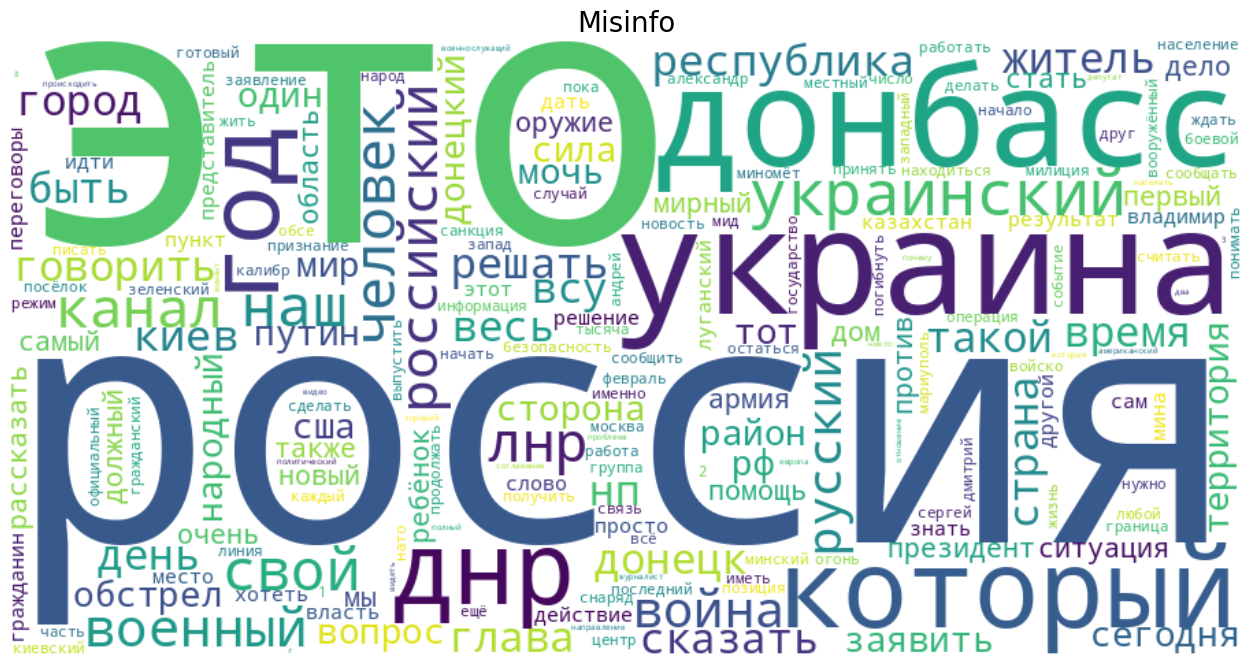

Top 20 words in Propaganda:


,word,count
0,россия,3789
1,украина,3089
2,это,2307
3,который,2145
4,заявить,1820
5,год,1790
6,российский,1732
7,рф,1455
8,сша,1441
9,сообщить,1379


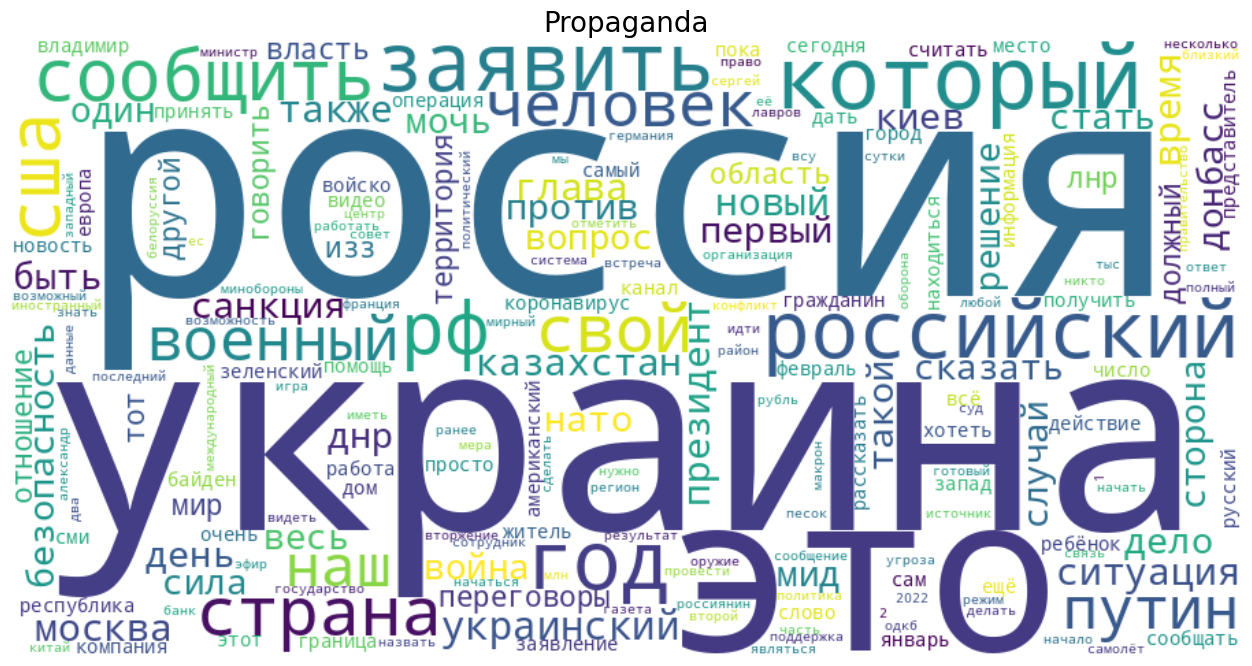

Top 20 words in Opposition:


,word,count
0,иностранный,7874
1,агент,5145
2,выполнять,5062
3,функция,5024
4,российский,4952
5,россия,4044
6,информация,2976
7,украина,2899
8,сообщение,2722
9,материал,2698


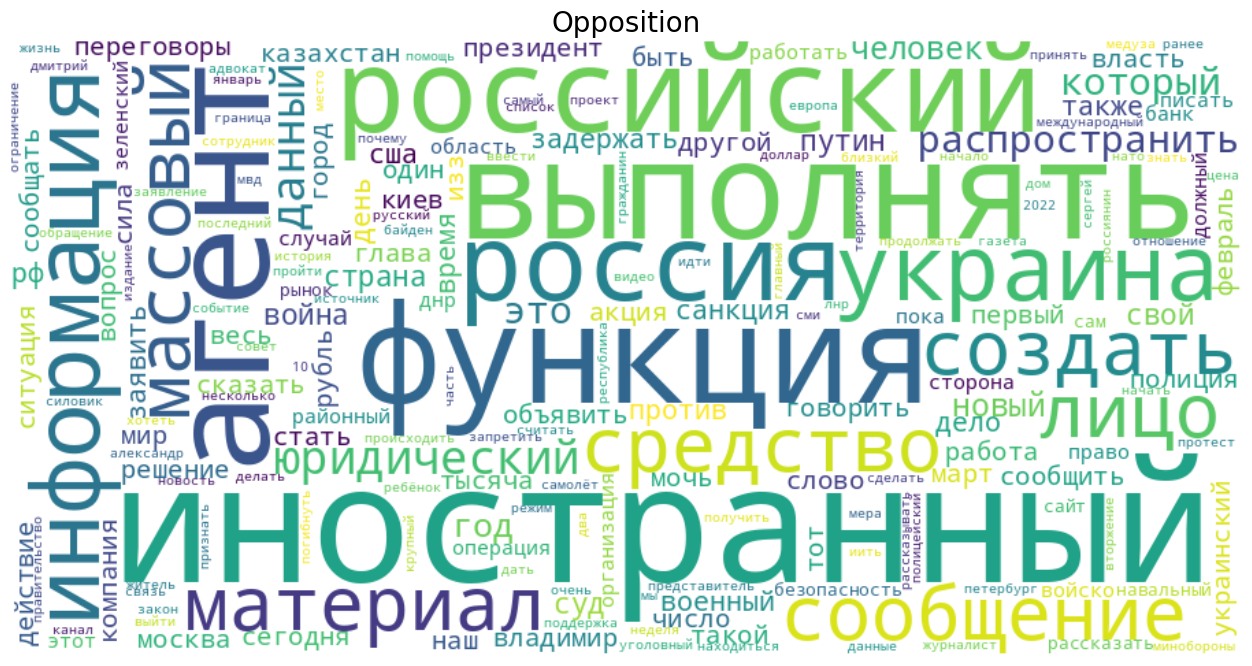

In [ ]:
from wordcloud import WordCloud
from collections import Counter

def generate_wordcloud(df, column, title):
    text = ' '.join(df[column].astype(str))
    tokens = re.findall(r'\w+', text.lower(), flags=re.UNICODE)
    counts = Counter(tokens)
    
    if not counts:
        print(f"No tokens found in {title}")
        return
    
    top20 = counts.most_common(20)
    print(f"Top 20 words in {title}:")
    display(pd.DataFrame(top20, columns=['word', 'count']))
    
    wc = WordCloud(width=900, height=450, background_color='white').generate_from_frequencies(counts)
    plt.figure(figsize=(16,8))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=20)
    plt.show()

for df, name in zip([misinfo, propaganda, opposition], ["Misinfo", "Propaganda", "Opposition"]):
    generate_wordcloud(df, "message_lemmatized", name)